# Modelagem com PyTorch — MLP para Predição de Churn

Notebook dedicado à construção, treinamento e avaliação de uma **Rede Neural (MLP)** utilizando PyTorch para o problema de churn.

**Etapas:**
1. Preparação dos Dados (replicando pipeline do `eda.ipynb`)
2. Arquitetura da MLP (PyTorch)
3. Loop de Treinamento com Batching e Early Stopping
4. Comparação MLP vs Modelos Baseline (6 métricas)
5. Análise de Trade-off de Custo: Falsos Positivos vs Falsos Negativos
6. Registro de Experimentos no MLflow

## 1. Setup e Preparação dos Dados

In [31]:
# Bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import (
    SelectKBest, chi2, mutual_info_classif, f_classif,
    RFE, SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)

# XGBoost / LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# MLflow
import mlflow
import mlflow.pytorch
import mlflow.sklearn

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


### 1.1 Carregamento e Pré-processamento

Replicamos o mesmo pipeline de dados do `eda.ipynb` para garantir comparabilidade.

In [20]:
# ── Carregar dados ────────────────────────────────────────────────
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
print(f"Shape original: {df_churn.shape}")

# ── Remover colunas iniciais ──────────────────────────────────────
df_churn = df_churn.drop(columns=['Count', 'CustomerID', 'Churn Reason'])

# ── Feature Engineering ───────────────────────────────────────────
# 1. Perfil de alto risco: Fibra óptica + Contrato mensal
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') &
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Idoso isolado: Senior + Sem parceiro + Sem dependentes
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') &
    (df_churn['Partner'] == 'No') &
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Contagem de serviços de internet contratados
servicos = ['Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df_churn['internet_services_count'] = sum(
    (df_churn[c] == 'Yes').astype(int) for c in servicos
)

# 4. Custo por mês de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

# ── Conversão de tipos ────────────────────────────────────────────
for col in df_churn.columns:
    try:
        df_churn[col] = pd.to_numeric(df_churn[col])
    except (ValueError, TypeError):
        pass

# Total Charges: converter para float e preencher nulos
df_churn['Total Charges'] = pd.to_numeric(df_churn['Total Charges'], errors='coerce')
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median())

# ── Remover colunas de leakage e geográficas ─────────────────────
colunas_vazar = ['Churn Score', 'CLTV', 'Churn Label']
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
colunas_drop = colunas_vazar + colunas_geograficas
df_churn = df_churn.drop(columns=[c for c in colunas_drop if c in df_churn.columns])

# ── One-Hot Encoding ──────────────────────────────────────────────
cat_cols = df_churn.select_dtypes(include=['object', 'category']).columns.tolist()
data_encoded = pd.get_dummies(df_churn, columns=cat_cols, drop_first=False)
bool_cols = data_encoded.select_dtypes(include=bool).columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

# ── Preparação X e y ──────────────────────────────────────────────
df_model = data_encoded.select_dtypes(include=[np.number]).copy()
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']
X = X.fillna(X.median())

print(f"Features disponíveis: {X.shape[1]}")
print(f"Distribuição do target:\n{y.value_counts(normalize=True).round(4)}")

Shape original: (7043, 33)
Features disponíveis: 51
Distribuição do target:
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64


### 1.1 Carregamento e Pré-processamento

Replicamos o mesmo pipeline de dados do `eda.ipynb` para garantir comparabilidade.

In [21]:
# ── Carregar dados ────────────────────────────────────────────────
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
print(f"Shape original: {df_churn.shape}")

# ── Remover colunas iniciais ──────────────────────────────────────
df_churn = df_churn.drop(columns=['Count', 'CustomerID', 'Churn Reason'])

# ── Feature Engineering ───────────────────────────────────────────
# 1. Perfil de alto risco: Fibra óptica + Contrato mensal
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') &
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Idoso isolado: Senior + Sem parceiro + Sem dependentes
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') &
    (df_churn['Partner'] == 'No') &
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Contagem de serviços de internet contratados
servicos = ['Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df_churn['internet_services_count'] = sum(
    (df_churn[c] == 'Yes').astype(int) for c in servicos
)

# 4. Custo por mês de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

# ── Conversão de tipos ────────────────────────────────────────────
for col in df_churn.columns:
    try:
        df_churn[col] = pd.to_numeric(df_churn[col])
    except (ValueError, TypeError):
        pass

# Total Charges: converter para float e preencher nulos
df_churn['Total Charges'] = pd.to_numeric(df_churn['Total Charges'], errors='coerce')
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median())

# ── Remover colunas de leakage e geográficas ─────────────────────
colunas_vazar = ['Churn Score', 'CLTV', 'Churn Label']
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
colunas_drop = colunas_vazar + colunas_geograficas
df_churn = df_churn.drop(columns=[c for c in colunas_drop if c in df_churn.columns])

# ── One-Hot Encoding ──────────────────────────────────────────────
cat_cols = df_churn.select_dtypes(include=['object', 'category']).columns.tolist()
data_encoded = pd.get_dummies(df_churn, columns=cat_cols, drop_first=False)
bool_cols = data_encoded.select_dtypes(include=bool).columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

# ── Preparação X e y ──────────────────────────────────────────────
df_model = data_encoded.select_dtypes(include=[np.number]).copy()
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']
X = X.fillna(X.median())

print(f"Features disponíveis: {X.shape[1]}")
print(f"Distribuição do target:\n{y.value_counts(normalize=True).round(4)}")

Shape original: (7043, 33)
Features disponíveis: 51
Distribuição do target:
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [22]:
# ── Train/Test Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# ── Seleção de Features (Top 30 — mesmo processo do eda.ipynb) ──
K = 30
scaler_mm = MinMaxScaler()
X_scaled = pd.DataFrame(scaler_mm.fit_transform(X_train), columns=X_train.columns)

# 1. SelectKBest — ANOVA
skb_f = SelectKBest(score_func=f_classif, k=K)
skb_f.fit(X_scaled, y_train)
anova_scores = pd.Series(skb_f.scores_, index=X_train.columns)

# 2. SelectKBest — Chi2
skb_chi2 = SelectKBest(score_func=chi2, k=K)
skb_chi2.fit(X_scaled, y_train)
chi2_scores = pd.Series(skb_chi2.scores_, index=X_train.columns)

# 3. Mutual Information
mi = mutual_info_classif(X_scaled, y_train, random_state=SEED)
mi_scores = pd.Series(mi, index=X_train.columns)

# 4. Correlação Pearson
corr_target = X_train.corrwith(y_train).abs()

# 5. Random Forest Feature Importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_temp.fit(X_train, y_train)
rf_scores = pd.Series(rf_temp.feature_importances_, index=X_train.columns)

# 6. RFE com Logistic Regression
lr_temp = LogisticRegression(max_iter=2000, random_state=SEED)
rfe = RFE(estimator=lr_temp, n_features_to_select=K)
rfe.fit(X_scaled, y_train)
rfe_ranking = pd.Series(rfe.ranking_, index=X_train.columns)

# 7. SelectFromModel
selector_rf = SelectFromModel(rf_temp, threshold='mean', prefit=True)
sfm_mask = pd.Series(selector_rf.get_support().astype(int), index=X_train.columns)

# ── Ranking Agregado ──────────────────────────────────────────────
all_methods = pd.DataFrame({
    'anova':    anova_scores,
    'chi2':     chi2_scores,
    'mi':       mi_scores,
    'pearson':  corr_target,
    'rf_imp':   rf_scores,
    'rfe':      (rfe_ranking.max() - rfe_ranking + 1),  # inverter ranking
    'sfm':      sfm_mask,
})

# Normalizar cada método para [0, 1] e somar
all_norm = (all_methods - all_methods.min()) / (all_methods.max() - all_methods.min() + 1e-10)
ranking_final = all_norm.sum(axis=1).sort_values(ascending=False)

features_selecionadas = ranking_final.head(K).index.tolist()
print(f"\nTop {K} features selecionadas:")
print(features_selecionadas)

X_train_sel = X_train[features_selecionadas]
X_test_sel = X_test[features_selecionadas]

print(f"\nShape treino: {X_train_sel.shape} | Shape teste: {X_test_sel.shape}")

X_train: (5634, 51) | X_test: (1409, 51)

Top 30 features selecionadas:
['cost_per_month', 'high_risk_profile', 'Contract_Month-to-month', 'Tenure Months', 'Online Security_No', 'Tech Support_No', 'Payment Method_Electronic check', 'Monthly Charges', 'Total Charges', 'Dependents_No', 'Contract_Two year', 'Internet Service_Fiber optic', 'Dependents_Yes', 'Online Security_No internet service', 'Device Protection_No internet service', 'Streaming Movies_No internet service', 'Online Backup_No internet service', 'Streaming TV_No internet service', 'Tech Support_No internet service', 'Internet Service_No', 'Paperless Billing_No', 'Contract_One year', 'internet_services_count', 'Online Security_Yes', 'Online Backup_No', 'Tech Support_Yes', 'Partner_No', 'isolated_senior', 'Device Protection_No', 'Internet Service_DSL']

Shape treino: (5634, 30) | Shape teste: (1409, 30)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

print(f"Média das features (treino): {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"Desvio padrão (treino): {X_train_scaled.std(axis=0)[:5].round(6)}")

Média das features (treino): [ 0.  0.  0. -0.  0.]
Desvio padrão (treino): [1. 1. 1. 1. 1.]


---
## 2. Arquitetura da MLP (PyTorch)

```
Etapa 2: Modelagem com PyTorch
- Construir a arquitetura da Rede Neural (MLP), definindo funções de ativação e função de perda (loss).
- Implementar o loop de treinamento incluindo batching e early stopping.
```


Rede Neural do tipo **Multi-Layer Perceptron** com:
- 3 camadas ocultas (64 → 32 → 16 neurônios)
- Ativação **ReLU** nas camadas ocultas
- **Batch Normalization** para estabilizar o treinamento
- **Dropout** (0.3) para regularização
- Ativação **Sigmoid** na saída (classificação binária)
- Função de perda: **BCELoss** (Binary Cross-Entropy)
- Otimizador: **Adam**

In [24]:
class ChurnDataset(Dataset):
    """Dataset PyTorch para dados tabulares de churn."""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y.values if hasattr(y, 'values') else y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [25]:
class ChurnMLP(nn.Module):
    """
    Multi-Layer Perceptron para classificação binária de churn.

    Arquitetura:
        Input (n_features)
        → Linear(64) → BatchNorm → ReLU → Dropout(0.3)
        → Linear(32) → BatchNorm → ReLU → Dropout(0.3)
        → Linear(16) → BatchNorm → ReLU → Dropout(0.3)
        → Linear(1)  → Sigmoid
    """

    def __init__(self, n_features, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            # Camada 1: input → 64
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Camada 2: 64 → 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Camada 3: 32 → 16
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Saída: 16 → 1
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


# Instanciar modelo
n_features = X_train_scaled.shape[1]
modelo_mlp = ChurnMLP(n_features).to(DEVICE)
print(modelo_mlp)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in modelo_mlp.parameters()):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total de parâmetros: 4,833


---

```
Etapa 2: Modelagem com PyTorch
- Comparar os resultados da MLP contra os modelos baseline utilizando, no mínimo, 4 métricas diferentes.
- Realizar uma análise do trade-off de custo entre falsos positivos e falsos negativos.
- Registrar todos os experimentos da etapa no MLflow.
```


## 3. Loop de Treinamento com Batching e Early Stopping

In [26]:
def treinar_modelo(modelo, X_train, y_train, X_val, y_val,
                   epochs=200, batch_size=64, lr=1e-3,
                   patience=15, device=DEVICE):
    """
    Treina a MLP com batching e early stopping.

    Parâmetros
    ----------
    modelo : nn.Module
    X_train, y_train : dados de treino (numpy arrays)
    X_val, y_val : dados de validação (numpy arrays)
    epochs : int — número máximo de épocas
    batch_size : int — tamanho do batch
    lr : float — learning rate
    patience : int — épocas sem melhoria para early stopping
    device : torch.device

    Retorna
    -------
    dict com histórico de loss e métricas
    """
    # DataLoaders
    train_dataset = ChurnDataset(X_train, y_train)
    val_dataset = ChurnDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Loss e Optimizer
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    # Histórico
    historico = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    # Early stopping
    melhor_val_loss = float('inf')
    epocas_sem_melhoria = 0
    melhor_estado = None

    for epoch in range(epochs):
        # ── Treino ────────────────────────────────────────────────
        modelo.train()
        train_loss_total = 0.0
        train_corretos = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = modelo(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * X_batch.size(0)
            train_corretos += ((y_pred >= 0.5).float() == y_batch).sum().item()
            train_total += X_batch.size(0)

        train_loss = train_loss_total / train_total
        train_acc = train_corretos / train_total

        # ── Validação ─────────────────────────────────────────────
        modelo.eval()
        val_loss_total = 0.0
        val_corretos = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = modelo(X_batch)
                loss = criterion(y_pred, y_batch)

                val_loss_total += loss.item() * X_batch.size(0)
                val_corretos += ((y_pred >= 0.5).float() == y_batch).sum().item()
                val_total += X_batch.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_corretos / val_total

        # Registrar histórico
        historico['train_loss'].append(train_loss)
        historico['val_loss'].append(val_loss)
        historico['train_acc'].append(train_acc)
        historico['val_acc'].append(val_acc)

        # Early stopping
        if val_loss < melhor_val_loss:
            melhor_val_loss = val_loss
            epocas_sem_melhoria = 0
            melhor_estado = modelo.state_dict().copy()
        else:
            epocas_sem_melhoria += 1

        if (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if epocas_sem_melhoria >= patience:
            print(f"\n⚠ Early stopping na época {epoch+1} "
                  f"(sem melhoria por {patience} épocas)")
            break

    # Restaurar melhor modelo
    if melhor_estado is not None:
        modelo.load_state_dict(melhor_estado)
        print(f"Melhor val_loss: {melhor_val_loss:.4f}")

    return historico

In [27]:
# ── Treinar a MLP ─────────────────────────────────────────────────
EPOCHS = 200
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE = 15

modelo_mlp = ChurnMLP(n_features).to(DEVICE)

historico = treinar_modelo(
    modelo_mlp,
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    patience=PATIENCE,
)

Época  10/200 | Train Loss: 0.4187 | Val Loss: 0.4115 | Train Acc: 0.8014 | Val Acc: 0.8041
Época  20/200 | Train Loss: 0.4036 | Val Loss: 0.4118 | Train Acc: 0.7989 | Val Acc: 0.7999
Época  30/200 | Train Loss: 0.4005 | Val Loss: 0.4106 | Train Acc: 0.8115 | Val Acc: 0.8034
Época  40/200 | Train Loss: 0.4020 | Val Loss: 0.4113 | Train Acc: 0.8135 | Val Acc: 0.7999

⚠ Early stopping na época 44 (sem melhoria por 15 épocas)
Melhor val_loss: 0.4082


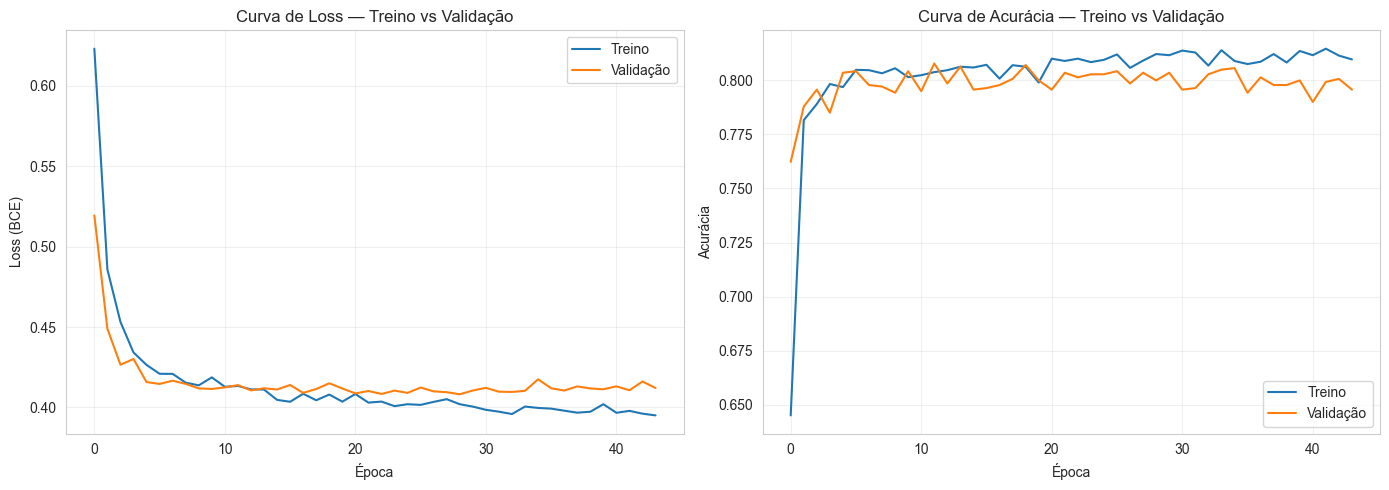

In [28]:
# ── Curvas de Treinamento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(historico['train_loss'], label='Treino')
axes[0].plot(historico['val_loss'], label='Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Curva de Loss — Treino vs Validação')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(historico['train_acc'], label='Treino')
axes[1].plot(historico['val_acc'], label='Validação')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Curva de Acurácia — Treino vs Validação')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/curvas_treinamento_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Comparação MLP vs Modelos Baseline

Comparamos a MLP contra 4 modelos baseline utilizando **6 métricas**:
1. **Accuracy** — proporção de acertos totais
2. **Precision** — proporção de verdadeiros positivos entre os preditos como positivos
3. **Recall** — proporção de verdadeiros positivos entre os realmente positivos
4. **F1-Score** — média harmônica de Precision e Recall
5. **ROC-AUC** — área sob a curva ROC
6. **MCC** (Matthews Correlation Coefficient) — métrica balanceada para classes desbalanceadas

In [32]:
def avaliar_modelo(nome, y_true, y_pred, y_proba):
    """Calcula as 6 métricas de avaliação para um modelo."""
    return {
        'Modelo': nome,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }


def predizer_mlp(modelo, X, device=DEVICE):
    """Gera probabilidades e predições da MLP."""
    modelo.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X).to(device)
        proba = modelo(X_tensor).cpu().numpy()
    pred = (proba >= 0.5).astype(int)
    return pred, proba

In [33]:
# ── Predições da MLP ──────────────────────────────────────────────
mlp_pred, mlp_proba = predizer_mlp(modelo_mlp, X_test_scaled)

# ── Treinar Modelos Baseline ─────────────────────────────────────
# Usamos as features selecionadas (sem scaling para tree-based, com scaling para LR)
baselines = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=SEED, n_jobs=-1, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        random_state=SEED, n_jobs=-1, verbose=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=SEED
    ),
}

resultados = []

# MLP (já treinada)
resultados.append(avaliar_modelo('MLP (PyTorch)', y_test, mlp_pred, mlp_proba))

# Baselines
modelos_treinados = {}
for nome, modelo_base in baselines.items():
    # Logistic Regression usa dados escalados
    if nome == 'Logistic Regression':
        modelo_base.fit(X_train_scaled, y_train)
        y_pred_base = modelo_base.predict(X_test_scaled)
        y_proba_base = modelo_base.predict_proba(X_test_scaled)[:, 1]
    else:
        modelo_base.fit(X_train_sel, y_train)
        y_pred_base = modelo_base.predict(X_test_sel)
        y_proba_base = modelo_base.predict_proba(X_test_sel)[:, 1]

    modelos_treinados[nome] = modelo_base
    resultados.append(avaliar_modelo(nome, y_test, y_pred_base, y_proba_base))
    print(f"{nome}: treinado")

# ── Tabela Comparativa ────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

# Formatar para exibição
print("\n" + "═" * 90)
print("COMPARAÇÃO DE MODELOS — 6 MÉTRICAS")
print("═" * 90)
display(df_resultados.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'MCC': '{:.4f}'
}).highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC'],
                color='lightgreen'))

Random Forest: treinado
XGBoost: treinado
LightGBM: treinado
Logistic Regression: treinado

══════════════════════════════════════════════════════════════════════════════════════════
COMPARAÇÃO DE MODELOS — 6 MÉTRICAS
══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC
0,Logistic Regression,0.8027,0.6519,0.5508,0.5971,0.8516,0.4706
1,MLP (PyTorch),0.7956,0.6162,0.6096,0.6129,0.8486,0.4741
2,XGBoost,0.7970,0.6350,0.5535,0.5914,0.8430,0.4591
3,Random Forest,0.7935,0.6301,0.5374,0.5801,0.8405,0.4468
4,LightGBM,0.7899,0.6168,0.5508,0.5819,0.8366,0.4435


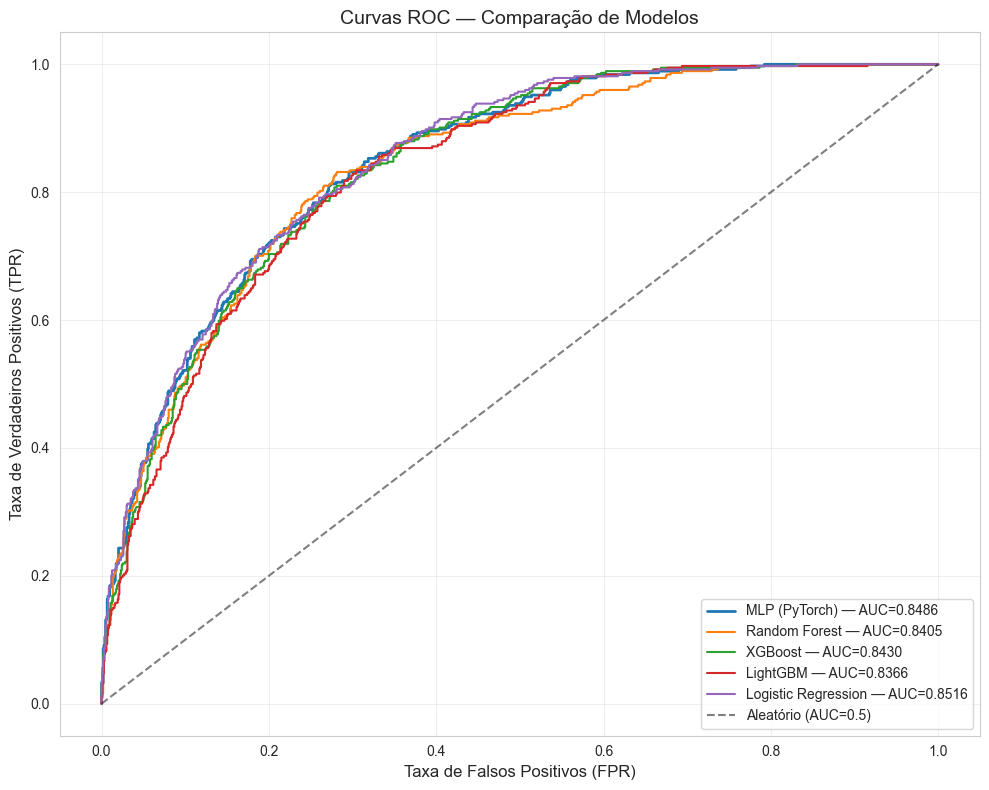

In [34]:
# ── Curvas ROC Comparativas ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_proba)
auc_mlp = roc_auc_score(y_test, mlp_proba)
ax.plot(fpr_mlp, tpr_mlp, linewidth=2, label=f'MLP (PyTorch) — AUC={auc_mlp:.4f}')

# Baselines
for nome, modelo_base in modelos_treinados.items():
    if nome == 'Logistic Regression':
        y_proba_base = modelo_base.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba_base = modelo_base.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_base)
    auc_val = roc_auc_score(y_test, y_proba_base)
    ax.plot(fpr, tpr, linewidth=1.5, label=f'{nome} — AUC={auc_val:.4f}')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatório (AUC=0.5)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação de Modelos', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/curvas_roc_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

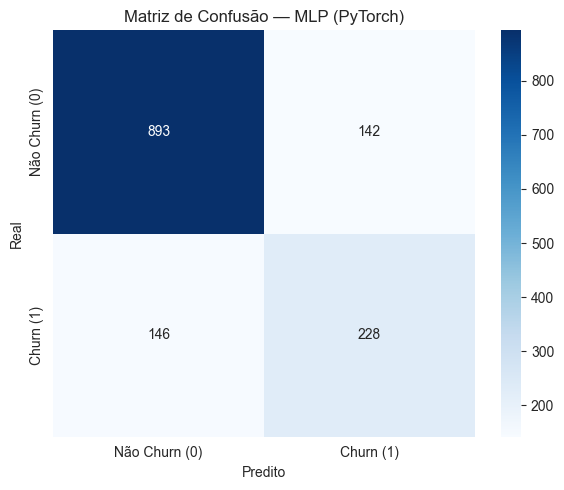


Relatório de Classificação — MLP (PyTorch):
              precision    recall  f1-score   support

   Não Churn       0.86      0.86      0.86      1035
       Churn       0.62      0.61      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.79      0.80      0.80      1409



In [35]:
# ── Matriz de Confusão da MLP ─────────────────────────────────────
cm = confusion_matrix(y_test, mlp_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Não Churn (0)', 'Churn (1)'],
            yticklabels=['Não Churn (0)', 'Churn (1)'])
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — MLP (PyTorch)')

plt.tight_layout()
plt.savefig('../docs/matriz_confusao_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRelatório de Classificação — MLP (PyTorch):")
print(classification_report(y_test, mlp_pred, target_names=['Não Churn', 'Churn']))

---
## 5. Análise de Trade-off de Custo: Falsos Positivos vs Falsos Negativos

Em um cenário real de churn, os custos de erros são assimétricos:

| Tipo de Erro | Descrição | Custo Estimado |
|---|---|---|
| **Falso Positivo (FP)** | Cliente que não ia cancelar recebe oferta de retenção desnecessária | R$ 50 (custo da campanha) |
| **Falso Negativo (FN)** | Cliente que ia cancelar não é detectado e é perdido | R$ 500 (receita perdida) |

A razão custo FN/FP = 10:1 reflete que perder um cliente é muito mais caro do que fazer uma oferta desnecessária.

Vamos analisar como o **threshold de decisão** afeta o custo total.

In [36]:
# ── Custos de Negócio ─────────────────────────────────────────────
CUSTO_FP = 50    # R$ — oferta de retenção desnecessária
CUSTO_FN = 500   # R$ — perda do cliente

# ── Análise por Threshold ─────────────────────────────────────────
thresholds = np.arange(0.05, 0.96, 0.01)

analise_threshold = []
for t in thresholds:
    y_pred_t = (mlp_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    custo_total = (fp * CUSTO_FP) + (fn * CUSTO_FN)

    analise_threshold.append({
        'threshold': t,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'custo_total': custo_total,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
    })

df_threshold = pd.DataFrame(analise_threshold)

# ── Threshold ótimo ───────────────────────────────────────────────
idx_otimo = df_threshold['custo_total'].idxmin()
threshold_otimo = df_threshold.loc[idx_otimo, 'threshold']
custo_otimo = df_threshold.loc[idx_otimo, 'custo_total']

idx_padrao = (df_threshold['threshold'] - 0.5).abs().idxmin()
custo_padrao = df_threshold.loc[idx_padrao, 'custo_total']

print(f"Threshold padrão (0.50): Custo total = R$ {custo_padrao:,.0f}")
print(f"Threshold ótimo ({threshold_otimo:.2f}): Custo total = R$ {custo_otimo:,.0f}")
print(f"Economia: R$ {custo_padrao - custo_otimo:,.0f} ({(1 - custo_otimo/custo_padrao)*100:.1f}%)")

Threshold padrão (0.50): Custo total = R$ 80,100
Threshold ótimo (0.05): Custo total = R$ 34,100
Economia: R$ 46,000 (57.4%)


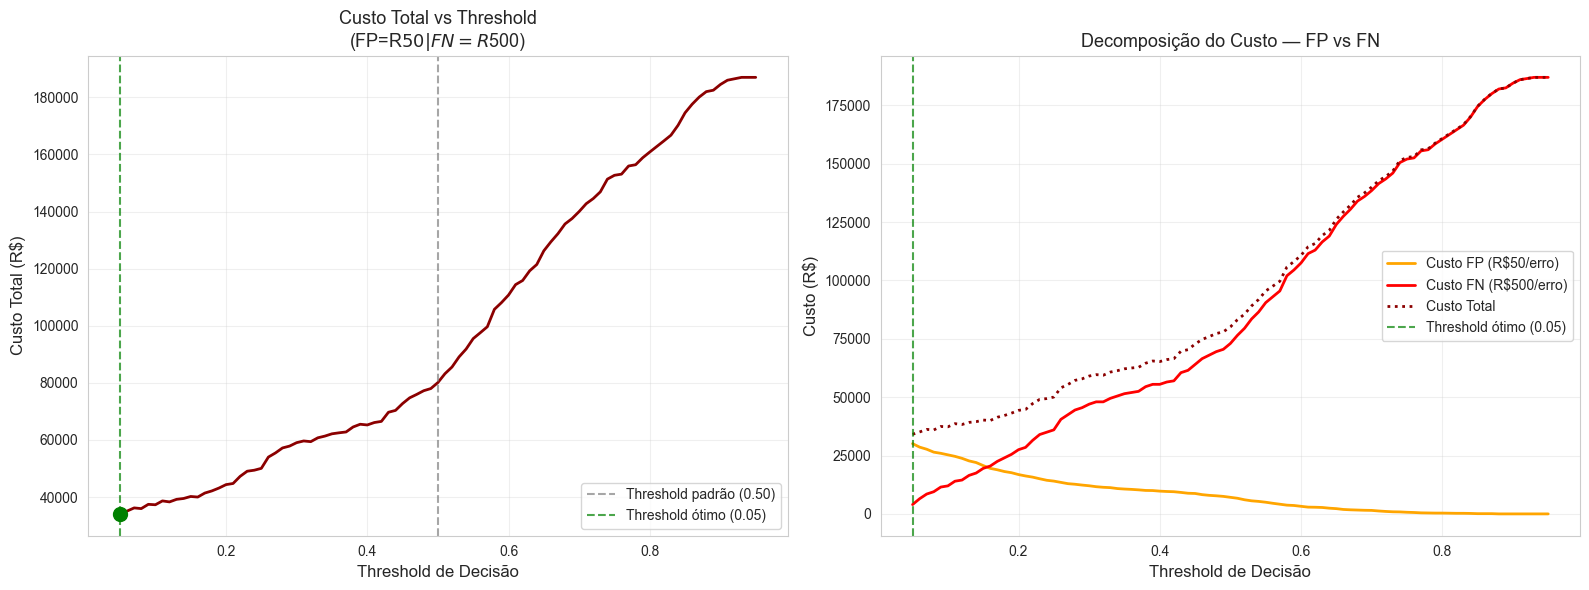

In [37]:
# ── Gráfico: Custo Total vs Threshold ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Custo total
ax1 = axes[0]
ax1.plot(df_threshold['threshold'], df_threshold['custo_total'],
         color='darkred', linewidth=2)
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label=f'Threshold padrão (0.50)')
ax1.axvline(x=threshold_otimo, color='green', linestyle='--', alpha=0.7,
            label=f'Threshold ótimo ({threshold_otimo:.2f})')
ax1.scatter([threshold_otimo], [custo_otimo], color='green', s=100, zorder=5)
ax1.set_xlabel('Threshold de Decisão', fontsize=12)
ax1.set_ylabel('Custo Total (R$)', fontsize=12)
ax1.set_title(f'Custo Total vs Threshold\n(FP=R${CUSTO_FP} | FN=R${CUSTO_FN})', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Componentes do custo
ax2 = axes[1]
ax2.plot(df_threshold['threshold'], df_threshold['FP'] * CUSTO_FP,
         color='orange', linewidth=2, label=f'Custo FP (R${CUSTO_FP}/erro)')
ax2.plot(df_threshold['threshold'], df_threshold['FN'] * CUSTO_FN,
         color='red', linewidth=2, label=f'Custo FN (R${CUSTO_FN}/erro)')
ax2.plot(df_threshold['threshold'], df_threshold['custo_total'],
         color='darkred', linewidth=2, linestyle=':', label='Custo Total')
ax2.axvline(x=threshold_otimo, color='green', linestyle='--', alpha=0.7,
            label=f'Threshold ótimo ({threshold_otimo:.2f})')
ax2.set_xlabel('Threshold de Decisão', fontsize=12)
ax2.set_ylabel('Custo (R$)', fontsize=12)
ax2.set_title('Decomposição do Custo — FP vs FN', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/analise_custo_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

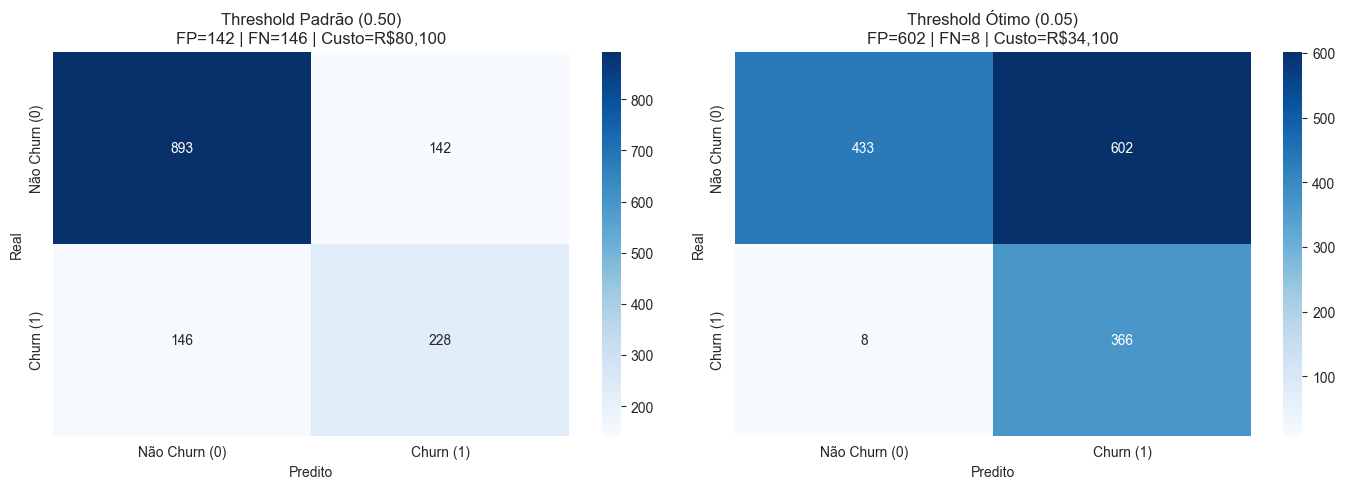

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC
0,MLP — Threshold 0.50,0.7956,0.6162,0.6096,0.6129,0.8486,0.4741
1,MLP — Threshold 0.05,0.5671,0.3781,0.9786,0.5455,0.8486,0.3780


In [38]:
# ── Matrizes de Confusão: Threshold Padrão vs Ótimo ──────────────
y_pred_padrao = (mlp_proba >= 0.5).astype(int)
y_pred_otimo = (mlp_proba >= threshold_otimo).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, titulo, t in zip(
    axes,
    [y_pred_padrao, y_pred_otimo],
    ['Threshold Padrão (0.50)', f'Threshold Ótimo ({threshold_otimo:.2f})'],
    [0.5, threshold_otimo]
):
    cm_t = confusion_matrix(y_test, y_p)
    tn, fp, fn, tp = cm_t.ravel()
    custo = fp * CUSTO_FP + fn * CUSTO_FN

    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Não Churn (0)', 'Churn (1)'],
                yticklabels=['Não Churn (0)', 'Churn (1)'])
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_title(f'{titulo}\nFP={fp} | FN={fn} | Custo=R${custo:,.0f}')

plt.tight_layout()
plt.savefig('../docs/matrizes_confusao_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Métricas comparativas nos dois thresholds ─────────────────────
metricas_threshold = pd.DataFrame([
    avaliar_modelo('MLP — Threshold 0.50', y_test, y_pred_padrao, mlp_proba),
    avaliar_modelo(f'MLP — Threshold {threshold_otimo:.2f}', y_test, y_pred_otimo, mlp_proba),
])
display(metricas_threshold.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'MCC': '{:.4f}'
}))

---
## 6. Registro de Experimentos no MLflow

Registramos todos os modelos (MLP + baselines) com seus parâmetros, métricas e artefatos.

In [39]:
# ── Configurar MLflow ─────────────────────────────────────────────
mlflow.set_tracking_uri("mlruns")
EXPERIMENT_NAME = "churn-prediction-pytorch"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow experiment: {EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

MLflow experiment: churn-prediction-pytorch
Tracking URI: mlruns


In [40]:
# ── Registrar MLP no MLflow ───────────────────────────────────────
with mlflow.start_run(run_name="MLP_PyTorch"):
    # Parâmetros
    mlflow.log_param("modelo", "MLP (PyTorch)")
    mlflow.log_param("arquitetura", "30→64→32→16→1")
    mlflow.log_param("ativacao_hidden", "ReLU")
    mlflow.log_param("ativacao_saida", "Sigmoid")
    mlflow.log_param("loss_function", "BCELoss")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("max_epochs", EPOCHS)
    mlflow.log_param("early_stopping_patience", PATIENCE)
    mlflow.log_param("dropout_rate", 0.3)
    mlflow.log_param("batch_normalization", True)
    mlflow.log_param("n_features", n_features)
    mlflow.log_param("epochs_treinadas", len(historico['train_loss']))

    # Métricas (threshold padrão 0.5)
    mlp_metrics = df_resultados[df_resultados['Modelo'] == 'MLP (PyTorch)'].iloc[0]
    mlflow.log_metric("accuracy", mlp_metrics['Accuracy'])
    mlflow.log_metric("precision", mlp_metrics['Precision'])
    mlflow.log_metric("recall", mlp_metrics['Recall'])
    mlflow.log_metric("f1_score", mlp_metrics['F1-Score'])
    mlflow.log_metric("roc_auc", mlp_metrics['ROC-AUC'])
    mlflow.log_metric("mcc", mlp_metrics['MCC'])

    # Métricas com threshold ótimo
    mlflow.log_metric("threshold_otimo", threshold_otimo)
    mlflow.log_metric("custo_total_threshold_padrao", custo_padrao)
    mlflow.log_metric("custo_total_threshold_otimo", custo_otimo)

    # Artefatos (gráficos)
    mlflow.log_artifact("../docs/curvas_treinamento_mlp.png")
    mlflow.log_artifact("../docs/curvas_roc_comparacao.png")
    mlflow.log_artifact("../docs/matriz_confusao_mlp.png")
    mlflow.log_artifact("../docs/analise_custo_threshold.png")
    mlflow.log_artifact("../docs/matrizes_confusao_threshold.png")

    # Salvar modelo PyTorch
    mlflow.pytorch.log_model(modelo_mlp, "modelo_mlp")

    print("MLP registrada no MLflow")

2026/03/23 19:54:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 19:54:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 19:54:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLP registrada no MLflow


In [41]:
# ── Registrar Modelos Baseline no MLflow ──────────────────────────
for nome, modelo_base in modelos_treinados.items():
    run_name = nome.replace(' ', '_')

    with mlflow.start_run(run_name=run_name):
        # Parâmetros
        mlflow.log_param("modelo", nome)
        params = modelo_base.get_params()
        for k, v in params.items():
            try:
                mlflow.log_param(k, v)
            except Exception:
                pass  # Ignorar parâmetros que não podem ser serializados

        # Métricas
        metricas_modelo = df_resultados[df_resultados['Modelo'] == nome].iloc[0]
        mlflow.log_metric("accuracy", metricas_modelo['Accuracy'])
        mlflow.log_metric("precision", metricas_modelo['Precision'])
        mlflow.log_metric("recall", metricas_modelo['Recall'])
        mlflow.log_metric("f1_score", metricas_modelo['F1-Score'])
        mlflow.log_metric("roc_auc", metricas_modelo['ROC-AUC'])
        mlflow.log_metric("mcc", metricas_modelo['MCC'])

        # Salvar modelo sklearn
        mlflow.sklearn.log_model(modelo_base, f"modelo_{run_name.lower()}")

        print(f"{nome} registrado no MLflow")

2026/03/23 19:54:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 19:54:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 19:54:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 19:54:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 19:54:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, wh

Random Forest registrado no MLflow


2026/03/23 19:54:40 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/87/qh8kyw6n4bjcv5rnx1z830hw0000gq/T/tmpaxpx8o_m/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
2026/03/23 19:54:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 19:54:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 19:54:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.

XGBoost registrado no MLflow


2026/03/23 19:54:40 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/87/qh8kyw6n4bjcv5rnx1z830hw0000gq/T/tmpj6evdipd/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
2026/03/23 19:54:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 19:54:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 19:54:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.

LightGBM registrado no MLflow


2026/03/23 19:54:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logistic Regression registrado no MLflow


In [42]:
# ── Registrar Análise de Threshold no MLflow ─────────────────────
with mlflow.start_run(run_name="Analise_Threshold_Custo"):
    mlflow.log_param("modelo_base", "MLP (PyTorch)")
    mlflow.log_param("custo_fp", CUSTO_FP)
    mlflow.log_param("custo_fn", CUSTO_FN)
    mlflow.log_param("razao_custo_fn_fp", CUSTO_FN / CUSTO_FP)
    mlflow.log_param("threshold_padrao", 0.5)
    mlflow.log_param("threshold_otimo", threshold_otimo)

    mlflow.log_metric("custo_total_threshold_padrao", custo_padrao)
    mlflow.log_metric("custo_total_threshold_otimo", custo_otimo)
    mlflow.log_metric("economia_absoluta", custo_padrao - custo_otimo)
    mlflow.log_metric("economia_percentual", (1 - custo_otimo / custo_padrao) * 100)

    # Métricas no threshold ótimo
    otimo_row = df_threshold.loc[idx_otimo]
    mlflow.log_metric("recall_threshold_otimo", otimo_row['recall'])
    mlflow.log_metric("precision_threshold_otimo", otimo_row['precision'])
    mlflow.log_metric("f1_threshold_otimo", otimo_row['f1'])

    mlflow.log_artifact("../docs/analise_custo_threshold.png")
    mlflow.log_artifact("../docs/matrizes_confusao_threshold.png")

    # Salvar tabela de análise como CSV
    df_threshold.to_csv('../docs/analise_threshold.csv', index=False)
    mlflow.log_artifact("../docs/analise_threshold.csv")

    print("Análise de threshold registrada no MLflow")

Análise de threshold registrada no MLflow


In [43]:
# ── Resumo Final ──────────────────────────────────────────────────
print("═" * 90)
print("RESUMO DOS EXPERIMENTOS")
print("═" * 90)
print(f"\nModelos registrados no MLflow: {len(modelos_treinados) + 1}")
print(f"  - MLP (PyTorch): {len(historico['train_loss'])} épocas treinadas")
for nome in modelos_treinados:
    print(f"  - {nome}")
print(f"\nAnálise de custo:")
print(f"  - Custo FP: R$ {CUSTO_FP} | Custo FN: R$ {CUSTO_FN}")
print(f"  - Threshold padrão (0.50): R$ {custo_padrao:,.0f}")
print(f"  - Threshold ótimo ({threshold_otimo:.2f}): R$ {custo_otimo:,.0f}")
print(f"  - Economia: R$ {custo_padrao - custo_otimo:,.0f}")
print(f"\nPara visualizar os experimentos:")
print(f"  $ mlflow ui --backend-store-uri mlruns")
print(f"  Acesse: http://localhost:5000")
print("\n" + "═" * 90)

display(df_resultados.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'MCC': '{:.4f}'
}).highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC'],
                color='lightgreen'))

══════════════════════════════════════════════════════════════════════════════════════════
RESUMO DOS EXPERIMENTOS
══════════════════════════════════════════════════════════════════════════════════════════

Modelos registrados no MLflow: 5
  - MLP (PyTorch): 44 épocas treinadas
  - Random Forest
  - XGBoost
  - LightGBM
  - Logistic Regression

Análise de custo:
  - Custo FP: R$ 50 | Custo FN: R$ 500
  - Threshold padrão (0.50): R$ 80,100
  - Threshold ótimo (0.05): R$ 34,100
  - Economia: R$ 46,000

Para visualizar os experimentos:
  $ mlflow ui --backend-store-uri mlruns
  Acesse: http://localhost:5000

══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC
0,Logistic Regression,0.8027,0.6519,0.5508,0.5971,0.8516,0.4706
1,MLP (PyTorch),0.7956,0.6162,0.6096,0.6129,0.8486,0.4741
2,XGBoost,0.7970,0.6350,0.5535,0.5914,0.8430,0.4591
3,Random Forest,0.7935,0.6301,0.5374,0.5801,0.8405,0.4468
4,LightGBM,0.7899,0.6168,0.5508,0.5819,0.8366,0.4435
